=== Hertz line contact: cylinder on flat ===
Reduced modulus E'      = 4.710 GPa
Contact half-width b    = 51.99 µm  (full width 2b = 0.1040 mm)
Peak pressure p0        = 122.45 MPa
Average pressure p_avg  = 96.17 MPa  (should equal pi/4*p0 = 96.17 MPa)
b/R                     = 0.0520  (Hertz validity wants this small, e.g. <~0.1)
Geom scale b^2/(2R)     = 1.352 µm  (NOT elastic approach)
p0 / sigma_yc(flat)     = 0.98  (rough plasticity indicator)


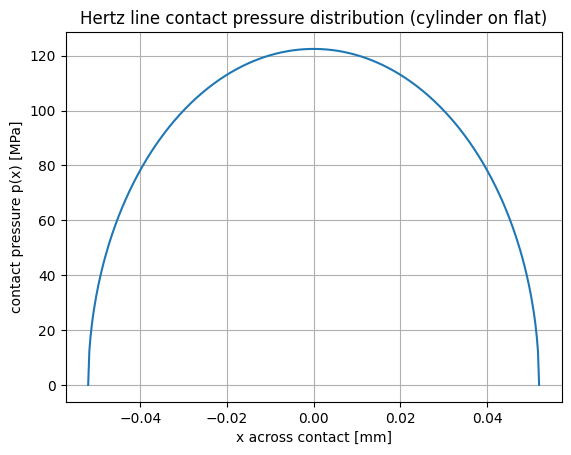

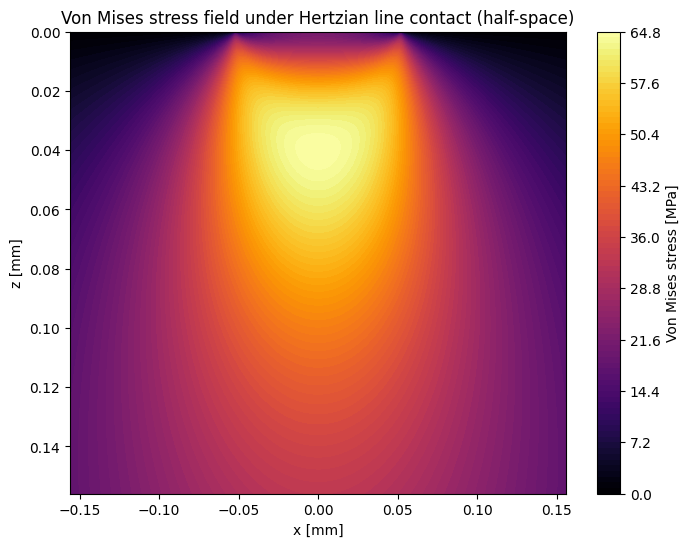

=== Centerline Von Mises under Hertz line contact (x=0) ===
a (contact half-width)              = 0.0520 mm
p0 (peak contact pressure)          = 122.45 MPa
Max Von Mises (numerical)           = 64.59 MPa
Depth of max Von Mises (numerical)  = 0.0400 mm  (= 0.769 a)
--- Sanity-check targets (typical Hertz line contact) ---
Expected depth ~ 0.78 a             = 0.0406 mm
Expected VM max ~ 0.62 p0           = 75.92 MPa


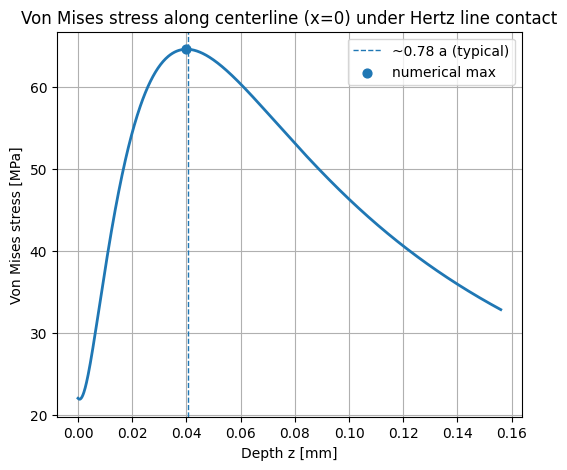

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Hertz line contact: cylinder on flat (plane) -> "line contact"
# Assumptions:
# - elastic, isotropic materials
# - small strains, frictionless normal contact
# - contact half-width b << cylinder radius R (Hertz validity)
# - contact length L is large enough that end effects are negligible
# ============================================================

# -----------------------
# 1) Inputs (SI units)
# -----------------------
# Body 1: Cylinder (e.g., steel-like values here)
E1 = 210e9         # Young's modulus [Pa]
nu1 = 0.30         # Poisson ratio [-]
R = 1e-3           # Cylinder radius [m]

# Body 2: Flat (e.g., PEEK 450G-like values)
E2 = 4.0e9         # Young's modulus [Pa]
nu2 = 0.41         # Poisson ratio [-]
sigma_yc_2 = 125e6 # Compressive yield/strength proxy [Pa] (datasheet dependent!)

# Geometry / load
L = 10e-3          # Effective contact length (axial) [m]
F = 100.0          # Total normal load over the length L [N]

# -----------------------
# 2) Reduced (composite) modulus E' (a.k.a. E*)
#    1/E' = (1-nu1^2)/E1 + (1-nu2^2)/E2
# -----------------------
Eprime = 1.0 / ((1.0 - nu1**2)/E1 + (1.0 - nu2**2)/E2)  # [Pa]

# -----------------------
# 3) Hertz line-contact results
# -----------------------
# Contact half-width b [m]
b = np.sqrt((4.0 * F * R) / (np.pi * L * Eprime))

# Peak pressure p0 (your Pmax) [Pa]
p0 = 2.0 * F / (np.pi * b * L)

# Average pressure over the rectangular footprint (2b x L) [Pa]
# Note: p_avg = F/(2bL) = (pi/4) * p0
p_avg = F / (2.0 * b * L)

# Pressure distribution across contact width
x = np.linspace(-b, b, 400)
p_x = p0 * np.sqrt(np.clip(1.0 - (x/b)**2, 0.0, 1.0))

# -----------------------
# 4) Quick validity / sanity checks
# -----------------------
b_over_R = b / R

# A rough geometric "gap" scale from cylinder curvature (NOT the Hertz elastic approach)
# Parabolic approx of cylinder: z ~ x^2/(2R) -> at x=b, z ~ b^2/(2R)
geom_scale = b**2 / (2.0 * R)

# Plasticity sanity check (very rough):
# For ductile metals, onset of yield in Hertz point/line contacts is often correlated with p0
# For polymers, datasheet "compressive strength" is time/temp dependent -> treat cautiously.
plasticity_ratio = p0 / sigma_yc_2  # >>1 suggests plasticity likely

# -----------------------
# 5) Print results (engineering-friendly)
# -----------------------
print("=== Hertz line contact: cylinder on flat ===")
print(f"Reduced modulus E'      = {Eprime/1e9:.3f} GPa")
print(f"Contact half-width b    = {b*1e6:.2f} µm  (full width 2b = {2*b*1e3:.4f} mm)")
print(f"Peak pressure p0        = {p0/1e6:.2f} MPa")
print(f"Average pressure p_avg  = {p_avg/1e6:.2f} MPa  (should equal pi/4*p0 = {(np.pi/4*p0)/1e6:.2f} MPa)")
print(f"b/R                     = {b_over_R:.4f}  (Hertz validity wants this small, e.g. <~0.1)")
print(f"Geom scale b^2/(2R)     = {geom_scale*1e6:.3f} µm  (NOT elastic approach)")
print(f"p0 / sigma_yc(flat)     = {plasticity_ratio:.2f}  (rough plasticity indicator)")

if b_over_R > 0.1:
    print("WARNING: b/R is not very small; Hertz assumptions may be questionable (large contact patch).")
if plasticity_ratio > 1.0:
    print("WARNING: Peak pressure exceeds your compressive strength proxy -> plasticity/creep likely (esp. polymer).")

# -----------------------
# 6) Plot pressure profile
# -----------------------
plt.figure()
plt.plot(x*1e3, p_x/1e6)
plt.xlabel("x across contact [mm]")
plt.ylabel("contact pressure p(x) [MPa]")
plt.title("Hertz line contact pressure distribution (cylinder on flat)")
plt.grid(True)
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Hertz line contact (frictionless): stress field in an elastic half-space
# Using the classical m,n auxiliary functions (Johnson-style closed forms).
#
# Coordinates:
#   x : along surface (across contact), x=0 under centerline
#   z : depth into the half-space, z>=0
#
# Sign convention:
#   compressive stresses are negative
#
# Assumptions:
#   - frictionless normal loading (no tangential traction)
#   - semi-elliptic pressure p(x)=p0*sqrt(1-(x/a)^2) for |x|<=a
#   - plane strain in out-of-plane direction (long contact length) if sigma_y used
# ------------------------------------------------------------

def m_fun(a, x, z):
    A = a*a - x*x + z*z
    B = np.sqrt(A*A + 4*x*x*z*z)
    return np.sqrt(0.5 * (B + A))

def n_fun(a, x, z):
    A = a*a - x*x + z*z
    B = np.sqrt(A*A + 4*x*x*z*z)
    return np.sqrt(0.5 * (B - A))

def _den(mv, nv, eps=1e-30):
    # Avoid division by zero near the contact edge (x=±a, z=0)
    return np.maximum(mv*mv + nv*nv, eps)

def sigma_x(p0, a, x, z):
    mv = m_fun(a, x, z)
    nv = n_fun(a, x, z)
    den = _den(mv, nv)
    return -(p0/a) * (mv * (1.0 + (z*z + nv*nv)/den) - 2.0*z)

def sigma_z(p0, a, x, z):
    mv = m_fun(a, x, z)
    nv = n_fun(a, x, z)
    den = _den(mv, nv)
    return -(p0/a) * mv * (1.0 - (z*z + nv*nv)/den)

def tau_xz(p0, a, x, z):
    mv = m_fun(a, x, z)
    nv = n_fun(a, x, z)
    den = _den(mv, nv)
    return -(p0/a) * nv * ((mv*mv - z*z) / den)

def sigma_y_plane_strain(p0, a, x, z, nu):
    # Plane strain assumption in the out-of-plane direction:
    sx = sigma_x(p0, a, x, z)
    sz = sigma_z(p0, a, x, z)
    return nu * (sx + sz)

def von_mises(p0, a, x, z, nu, plane_strain=True):
    sx = sigma_x(p0, a, x, z)
    sz = sigma_z(p0, a, x, z)
    txz = tau_xz(p0, a, x, z)

    if plane_strain:
        sy = sigma_y_plane_strain(p0, a, x, z, nu)
    else:
        sy = 0.0  # plane stress option

    return np.sqrt(0.5 * ((sx - sy)**2 + (sy - sz)**2 + (sz - sx)**2) + 3.0 * txz**2)

# ---- Example plotting ----
a = b      # contact half-width from Hertz solution
nu = nu2   # Poisson's ratio of the half-space (PEEK)

# Avoid exactly x=±a at z=0: use endpoints slightly inside
x_vals = np.linspace(-3*a, 3*a, 400)
z_vals = np.linspace(0, 3*a, 300)

X, Z = np.meshgrid(x_vals, z_vals)

VM = von_mises(p0, a, X, Z, nu, plane_strain=True) / 1e6  # MPa

plt.figure(figsize=(8,6))
cs = plt.contourf(X*1e3, Z*1e3, VM, levels=80, cmap="inferno")
plt.colorbar(cs, label="Von Mises stress [MPa]")
plt.xlabel("x [mm]")
plt.ylabel("z [mm]")
plt.title("Von Mises stress field under Hertzian line contact (half-space)")
plt.gca().invert_yaxis()
plt.show()

# ============================================================
# Centerline (x = 0) Von Mises stress vs depth z
# Using your sigma_von_mises(p0, a, x, z, nu) implementation
# Notes:
# - plane strain is assumed if your sigma_y() uses nu*(sx+sz)
# - compressive stresses are negative; Von Mises is positive
# - VM maximum for Hertz line contact is expected around z ~ 0.78 a
#   with magnitude ~ 0.62 p0 (good sanity check)
# ============================================================

# Fixed centerline location
x0 = 0.0

# Depth vector (avoid exactly z=0 if you want extra numerical robustness)
z_vals = np.linspace(1e-12, 3.0*a, 1000)  # [m]

# Von Mises along centerline (convert to MPa for plotting/printing)
vm_vals = von_mises(p0, a, x0, z_vals, nu2)          # [Pa]
vm_vals_mpa = vm_vals / 1e6                              # [MPa]

# Find maximum and its depth
imax = int(np.argmax(vm_vals))
z_max = z_vals[imax]                                     # [m]
vm_max = vm_vals[imax]                                   # [Pa]

# Optional: quick analytical expectations (Hertz line contact, plane strain)
z_expected = 0.78 * a
vm_expected = 0.62 * p0

print("=== Centerline Von Mises under Hertz line contact (x=0) ===")
print(f"a (contact half-width)              = {a*1e3:.4f} mm")
print(f"p0 (peak contact pressure)          = {p0/1e6:.2f} MPa")
print(f"Max Von Mises (numerical)           = {vm_max/1e6:.2f} MPa")
print(f"Depth of max Von Mises (numerical)  = {z_max*1e3:.4f} mm  (= {z_max/a:.3f} a)")
print("--- Sanity-check targets (typical Hertz line contact) ---")
print(f"Expected depth ~ 0.78 a             = {z_expected*1e3:.4f} mm")
print(f"Expected VM max ~ 0.62 p0           = {vm_expected/1e6:.2f} MPa")

# Plot Von Mises vs depth (surface at z=0)
plt.figure(figsize=(6, 5))
plt.plot(z_vals*1e3, vm_vals_mpa, linewidth=2)
plt.axvline(z_expected*1e3, linestyle="--", linewidth=1, label="~0.78 a (typical)")
plt.scatter([z_max*1e3], [vm_max/1e6], s=40, zorder=3, label="numerical max")
plt.xlabel("Depth z [mm]")
plt.ylabel("Von Mises stress [MPa]")
plt.title("Von Mises stress along centerline (x=0) under Hertz line contact")
plt.grid(True)
plt.legend()
plt.show()